In [1]:
import os
os.getcwd()

'C:\\Users\\PC'

In [2]:
os.chdir(r"D:\FQL\PJ 4")

### Section 1 : Import Libraries

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings, os, joblib
warnings.filterwarnings('ignore')

In [4]:
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error, r2_score

In [5]:
plt.rcParams.update({'figure.dpi': 120, 'axes.spines.top': False, 'axes.spines.right': False})
MODELS   = ['sarima', 'prophet', 'rf', 'xgb', 'lstm']
LABELS   = ['SARIMA', 'Prophet', 'Random Forest', 'XGBoost', 'LSTM']
PALETTE  = ['#1D4ED8', '#15803D', '#B91C1C', '#B45309', '#6D28D9']
M_COLOR  = dict(zip(MODELS, PALETTE))
M_LABEL  = dict(zip(MODELS, LABELS))
print('Ready.')

Ready.


### Section 2 : Laod the Predictions

In [6]:
preds = {}
for m in MODELS:
    path = f'predictions/{m}.csv'
    if os.path.exists(path):
        preds[m] = pd.read_csv(path, parse_dates=['Date'])
        print(f'  Loaded {path}  shape={preds[m].shape}')
    else:
        print(f'  NOT FOUND: {path}  — run NB3 first')

gt = pd.read_csv('predictions/ground_truth.csv', parse_dates=['Date'])
print(f'\nGround truth shape: {gt.shape}')

  Loaded predictions/sarima.csv  shape=(428, 3)
  Loaded predictions/prophet.csv  shape=(428, 3)
  Loaded predictions/rf.csv  shape=(428, 3)
  Loaded predictions/xgb.csv  shape=(428, 3)
  Loaded predictions/lstm.csv  shape=(414, 3)

Ground truth shape: (428, 2)


### Section 3 : Metric Comparison

In [7]:
def compute_metrics(y_true, y_pred, name):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    rmse  = np.sqrt(mean_squared_error(y_true, y_pred))
    mape  = mean_absolute_percentage_error(y_true, y_pred) * 100
    mae   = np.mean(np.abs(y_true - y_pred))
    r2    = r2_score(y_true, y_pred)
    smape = 100 * np.mean(2 * np.abs(y_pred - y_true) / (np.abs(y_true) + np.abs(y_pred) + 1e-8))
    bias  = np.mean(y_pred - y_true)
    return {'Model': name, 'RMSE': round(rmse,1), 'MAE': round(mae,1),
            'MAPE%': round(mape,2), 'sMAPE%': round(smape,2),
            'R²': round(r2,4), 'Bias': round(bias,1)}

In [8]:
records = []
for m, label in zip(MODELS, LABELS):
    if m in preds:
        p   = preds[m]
        rec = compute_metrics(p['y_true'], p['y_pred'], label)
        records.append(rec)

In [9]:
results_df = pd.DataFrame(records).set_index('Model').sort_values('RMSE')
print('=== Model Performance Comparison ===')
display(results_df.style
        .background_gradient(subset=['RMSE','MAE','MAPE%','sMAPE%'], cmap='RdYlGn_r')
        .background_gradient(subset=['R²'], cmap='RdYlGn')
        .format(precision=2))

=== Model Performance Comparison ===


,RMSE,MAE,MAPE%,sMAPE%,R²,Bias
Model,,,,,,
LSTM,353.50,260.20,7.03,7.02,0.91,4.70
Random Forest,380.40,278.80,7.59,7.14,0.90,114.70
XGBoost,416.80,317.90,8.47,7.92,0.88,232.10
Prophet,612.30,469.60,13.40,13.66,0.73,-125.70
SARIMA,1119.40,885.70,22.22,24.06,0.11,-595.70


In [10]:
best = results_df['RMSE'].idxmin()
print(f'\n Best model (RMSE): {best}')


 Best model (RMSE): LSTM


### SEction 4 : Comparison with BAR

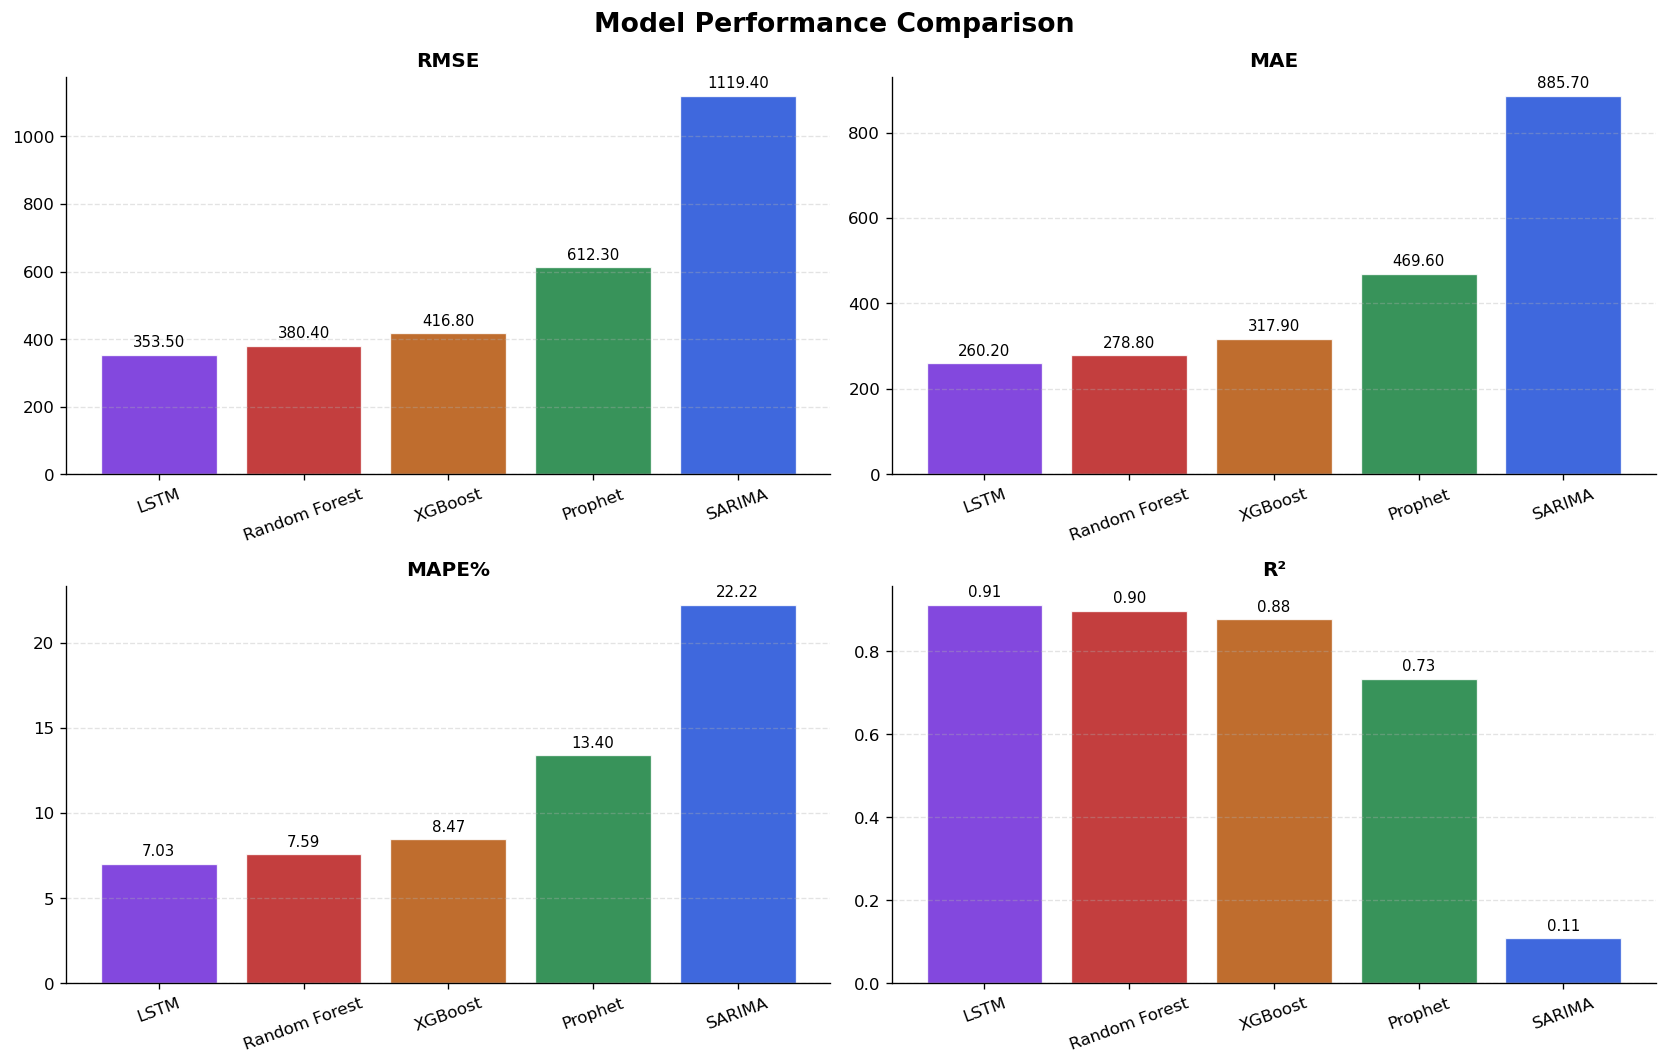

In [11]:
metrics_to_plot = ['RMSE', 'MAE', 'MAPE%', 'R²']
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle('Model Performance Comparison', fontsize=16, fontweight='bold')

for ax, metric in zip(axes.flat, metrics_to_plot):
    vals   = results_df[metric]
    colors = [PALETTE[LABELS.index(m)] for m in vals.index]
    bars   = ax.bar(vals.index, vals.values, color=colors, alpha=0.85, edgecolor='white', linewidth=0.8)
    ax.bar_label(bars, fmt='%.2f', padding=3, fontsize=9)
    ax.set_title(metric, fontsize=12, fontweight='bold')
    ax.tick_params(axis='x', rotation=20)
    ax.grid(axis='y', linestyle='--', alpha=0.35)

plt.tight_layout()
plt.savefig('plots/12_metric_comparison.png', bbox_inches='tight')
plt.show()

### Section 5 : Forecast VS Actual

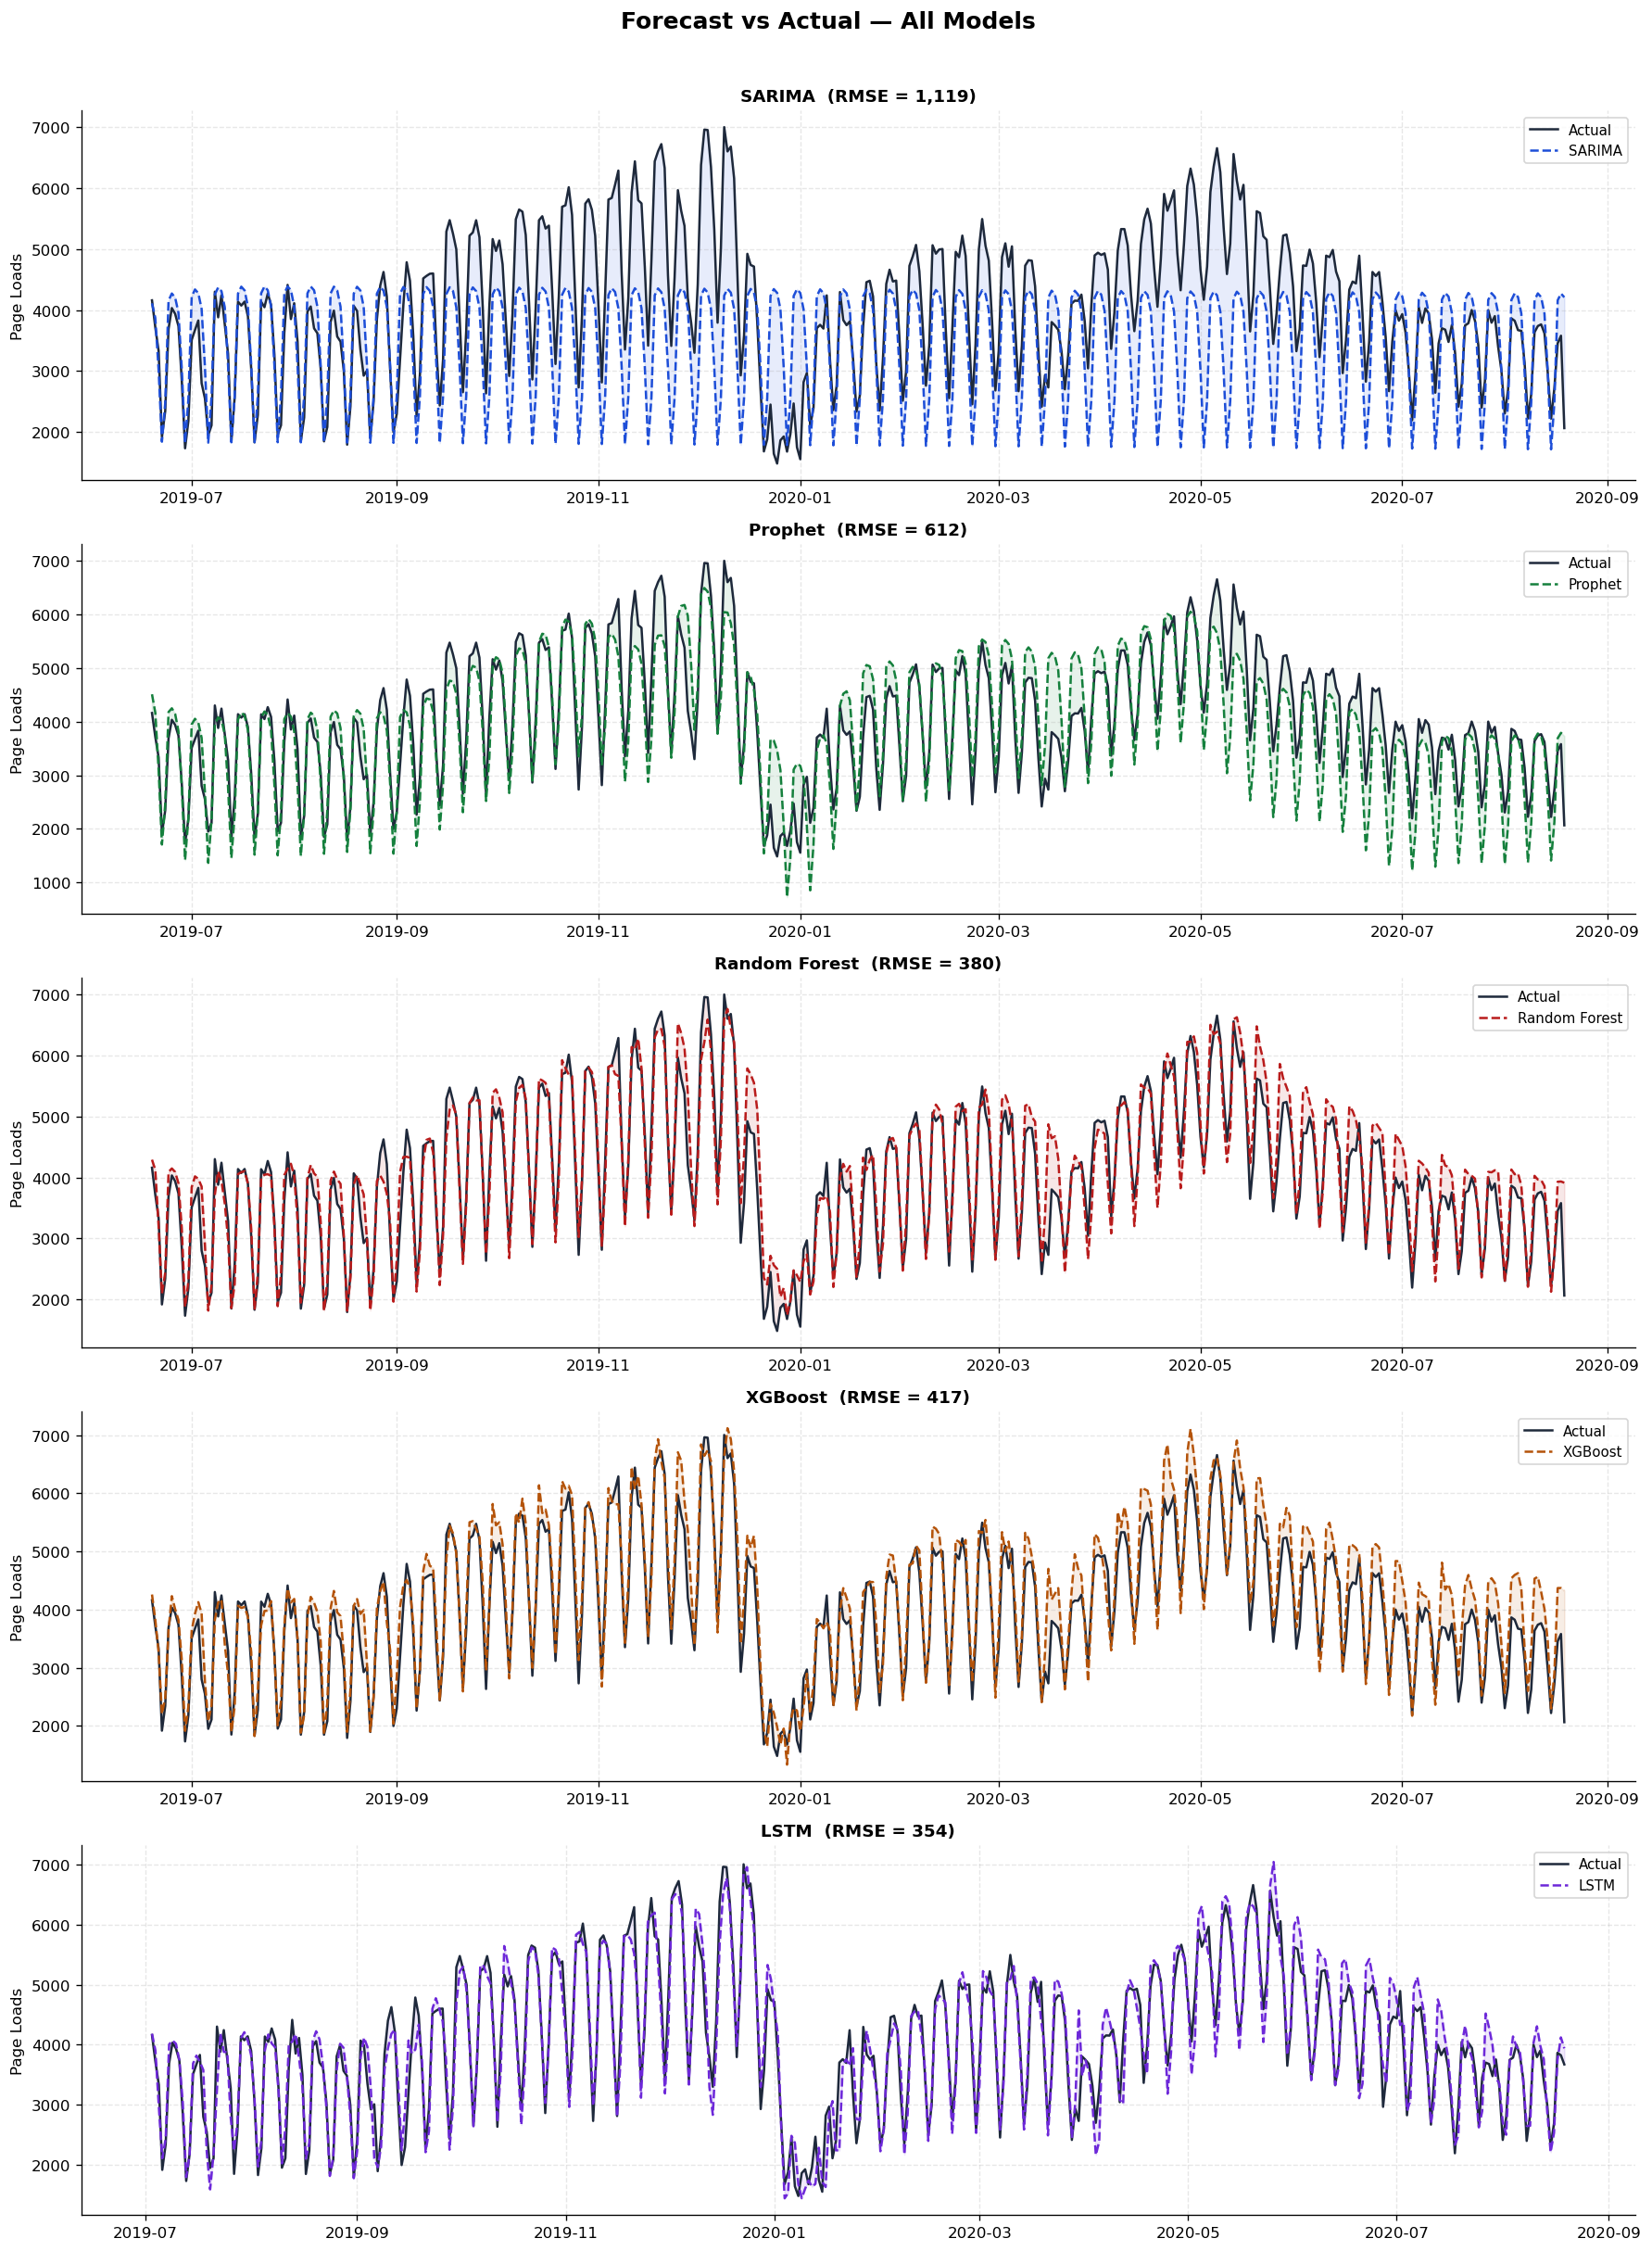

In [12]:
n_models = len(preds)
fig, axes = plt.subplots(n_models, 1, figsize=(15, 4 * n_models), sharex=False)
if n_models == 1: axes = [axes]
fig.suptitle('Forecast vs Actual — All Models', fontsize=15, fontweight='bold', y=1.01)

for ax, (m, label) in zip(axes, zip(MODELS, LABELS)):
    if m not in preds: continue
    p = preds[m]
    ax.plot(p['Date'], p['y_true'], color='#1E293B', lw=1.5, label='Actual')
    ax.plot(p['Date'], p['y_pred'], color=M_COLOR[m], lw=1.5, linestyle='--', label=label)
    ax.fill_between(p['Date'], p['y_true'], p['y_pred'],
                    alpha=0.10, color=M_COLOR[m])
    rmse_val = np.sqrt(mean_squared_error(p['y_true'], p['y_pred']))
    ax.set_title(f'{label}  (RMSE = {rmse_val:,.0f})', fontsize=11, fontweight='bold')
    ax.legend(loc='upper right', fontsize=9)
    ax.grid(True, linestyle='--', alpha=0.3)
    ax.set_ylabel('Page Loads')

plt.tight_layout()
plt.savefig('plots/13_forecast_panels.png', bbox_inches='tight')
plt.show()